In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [2]:
def get_gev_uncertainty(da_model, reference_return_values, name):
    """Get GEV uncertainty."""

    bootstrap_samples_dict = {}
    rng = np.random.default_rng(seed=0)
    n_bootstraps = 100
    for i in range(n_bootstraps):
        boot_data = rng.choice(da_model.values, size=da_model.shape, replace=True)
        gev_params = list(eva.fit_gev(boot_data))
        return_periods, return_values = stability.return_curve(boot_data, 'gev', params=gev_params)
        diff = return_values - reference_return_values
        bootstrap_samples_dict[i] = np.abs(diff)
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
#    df = df.drop([1.0])
    ds = df.var(axis=1)
    ds.name = name

    return ds


def get_return_values(metric, location, model_dict):
    """Get return values for each dataset."""
    
    return_values_dict = {}
    gev_spread_dict = {}

    da_obs = utils.get_obs_data(metric, location)
    da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)
    gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended = eva.fit_gev(da_obs_detrended.values)
    return_periods, return_values_obs = stability.return_curve(
        da_obs_detrended,
        'gev',
        params=[gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended],
    )
    return_values_dict[('obs', 'AGCD')] = return_values_obs
    gev_spread_obs = get_gev_uncertainty(
        da_obs_detrended,
        return_values_obs,
        name=('obs', 'AGCD'),
    )
    gev_spread_dict[('obs', 'AGCD')] = gev_spread_obs

    for model in model_dict:
        print(model)
        da_model_stacked = utils.get_model_data(metric, model, location)
        da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
        da_model_detrended_stacked_bc_mean = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
        da_model_detrended_stacked_bc_quantile = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)
        gev_model_detrended = list(eva.fit_gev(da_model_detrended_stacked.values))
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        gev_model_detrended_bc_quantile = list(eva.fit_gev(da_model_detrended_stacked_bc_quantile.values))
        return_periods, return_values_model_raw = stability.return_curve(
            da_model_detrended_stacked,
            'gev',
            params=gev_model_detrended,
        )
        gev_spread_model_raw = get_gev_uncertainty(
            da_model_detrended_stacked,
            return_values_model_raw,
            name=('model-raw', model),
        )
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        gev_spread_model_bc_mean = get_gev_uncertainty(
            da_model_detrended_stacked_bc_mean,
            return_values_model_bc_mean,
            name=('model-bc-mean', model),
        )
        return_periods, return_values_model_bc_quantile = stability.return_curve(
            da_model_detrended_stacked_bc_quantile,
            'gev',
            params=gev_model_detrended_bc_quantile,
        )
        gev_spread_model_bc_quantile = get_gev_uncertainty(
            da_model_detrended_stacked_bc_quantile,
            return_values_model_bc_quantile,
            name=('model-bc-quantile', model),
        )
        return_values_dict[('model-raw', model)] = return_values_model_raw
        return_values_dict[('model-bc-mean', model)] = return_values_model_bc_mean
        return_values_dict[('model-bc-quantile', model)] = return_values_model_bc_quantile
        gev_spread_dict[('model-raw', model)] = gev_spread_model_raw
        gev_spread_dict[('model-bc-mean', model)] = gev_spread_model_bc_mean
        gev_spread_dict[('model-bc-quantile', model)] = gev_spread_model_bc_quantile

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    gev_spread_df = pd.DataFrame(gev_spread_dict)
    gev_spread_df.index = return_periods
    gev_spread_df = gev_spread_df.drop([1.0])
    
    return return_values_df, gev_spread_df

In [3]:
def plot_uncertainty(
    ax,
    metric,
    return_df,
    gev_spread_df,
    ylim=[],
    plot_models=False,
    letter='',
):
    """Plot uncertainty."""
    
    gev_spread = gev_spread_df.filter(like='model-bc-mean').mean(axis=1)
    G2 = gev_spread
    G = np.sqrt(G2)

    model_bc_mean_spread = return_df.filter(like='model-bc-mean').var(axis=1)
    M2 = model_bc_mean_spread
    M = np.sqrt(M2)
    
    B2_models = []
    for bias_method, model in return_df.filter(like='model-bc-mean').columns.values:
        B2 = return_df[[('model-bc-mean', model), ('model-bc-quantile', model)]].var(axis=1)
        B2.name = model
        B2_models.append(B2)
    B2_ensemble = pd.concat(B2_models, axis=1)
    bias_spread = B2_ensemble.mean(axis=1)
    B2 = bias_spread
    B = np.sqrt(B2)

    T2 = G2 + M2 + B2
    T = np.sqrt(T2)
    F = (G + M + B) / T

    ave_model_bc_mean = return_df.filter(like='model-bc-mean').mean(axis=1)
    gev_spread_upper = ave_model_bc_mean + (1.654 * (G / F))
    gev_spread_lower = ave_model_bc_mean - (1.654 * (G / F)) 
    model_spread_upper = ave_model_bc_mean + (1.654 * ((G + M) / F))
    model_spread_lower = ave_model_bc_mean - (1.654 * ((G + M) / F))
    bias_spread_upper = ave_model_bc_mean + (1.654 * ((G + M + B) / F))
    bias_spread_lower = ave_model_bc_mean - (1.654 * ((G + M + B) / F))

    obs = return_df[('obs', 'AGCD')]
    gev_spread_obs = np.sqrt(gev_spread_df[('obs', 'AGCD')])
    gev_spread_obs_upper = obs + (1.654 * gev_spread_obs)
    gev_spread_obs_lower = obs - (1.654 * gev_spread_obs)
    
    return_periods = return_df.index.values

    if plot_models:
        count = 0
        for model in return_df.filter(like='model-bc-mean').columns.values:
            data = return_df[model].values
            if count == 0:
                ax.plot(return_periods, data, label='individual models (mean correction)', color='tab:blue', linewidth=0.7)
            else:
                ax.plot(return_periods, data, color='tab:blue', linewidth=0.7)
            count = count + 1
    
    ax.plot(return_periods, obs.values, label='observations', color='tab:red')
#    ax.fill_between(return_periods, obs.values, gev_spread_obs_upper.values, label='GEV uncertainty (obs)', color='tab:red', alpha=0.3)
#    ax.fill_between(return_periods, gev_spread_obs_lower.values, obs.values, color='tab:red', alpha=0.3)
    ax.plot(return_periods, gev_spread_obs_upper.values, label='uncertainty bounds (obs)', color='tab:red', linestyle=':')
    ax.plot(return_periods, gev_spread_obs_lower.values, color='tab:red', linestyle=':')
    
    ax.plot(return_periods, ave_model_bc_mean.values, label='multi-model mean', color='black')
    ax.plot(return_periods, bias_spread_upper.values, label='uncertainty bounds (model)', color='black', linestyle=':')
    ax.plot(return_periods, bias_spread_lower.values, color='black', linestyle=':')
    
    ax.fill_between(return_periods, ave_model_bc_mean.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_lower.values, ave_model_bc_mean.values, color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='model uncertainty', color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_upper.values, bias_spread_upper.values, label='bias correction uncertainty', color='tab:green', alpha=0.3)
    ax.fill_between(return_periods, bias_spread_lower.values, model_spread_lower.values, color='tab:green', alpha=0.3)

    legsize = 'x-large' if metric == 'rx1day' else 'large'
    ax.legend(fontsize=legsize)
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    metric_label = {'txx': 'TXx', 'rx1day': 'Rx1day'}
    ax.set_ylabel(f'{metric_label[metric]}')
    if letter:
        yloc = 0.05 if metric == 'rx1day' else 0.93
        ax.text(0.05, yloc, f'({letter})', transform=ax.transAxes, fontsize='xx-large')
#    ax.set_title('Return periods corresponding to GEV fits - ensemble')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

## rx1day

In [4]:
metric = 'rx1day'

In [5]:
location1 = [3, 10]
model_dict1 = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
#    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df1, gev_spread_df1 = get_return_values(metric, location1, model_dict1)

BCC-CSM2-MR
CAFE
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MRI-ESM2-0
NorCPM1


In [6]:
location2 = [9, 10]
model_dict2 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
#    'CanESM5': 'tab:red',
#    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
#    'MPI-ESM1-2-HR': 'tab:grey',
#    'MRI-ESM2-0': 'tab:olive',
#    'NorCPM1': 'tab:cyan',
}
return_df2, gev_spread_df2 = get_return_values(metric, location2, model_dict2)

BCC-CSM2-MR
CMCC-CM2-SR5
IPSL-CM6A-LR
MIROC6


In [7]:
location3 = [0, 11]
model_dict3 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df3, gev_spread_df3 = get_return_values(metric, location3, model_dict3)

BCC-CSM2-MR
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


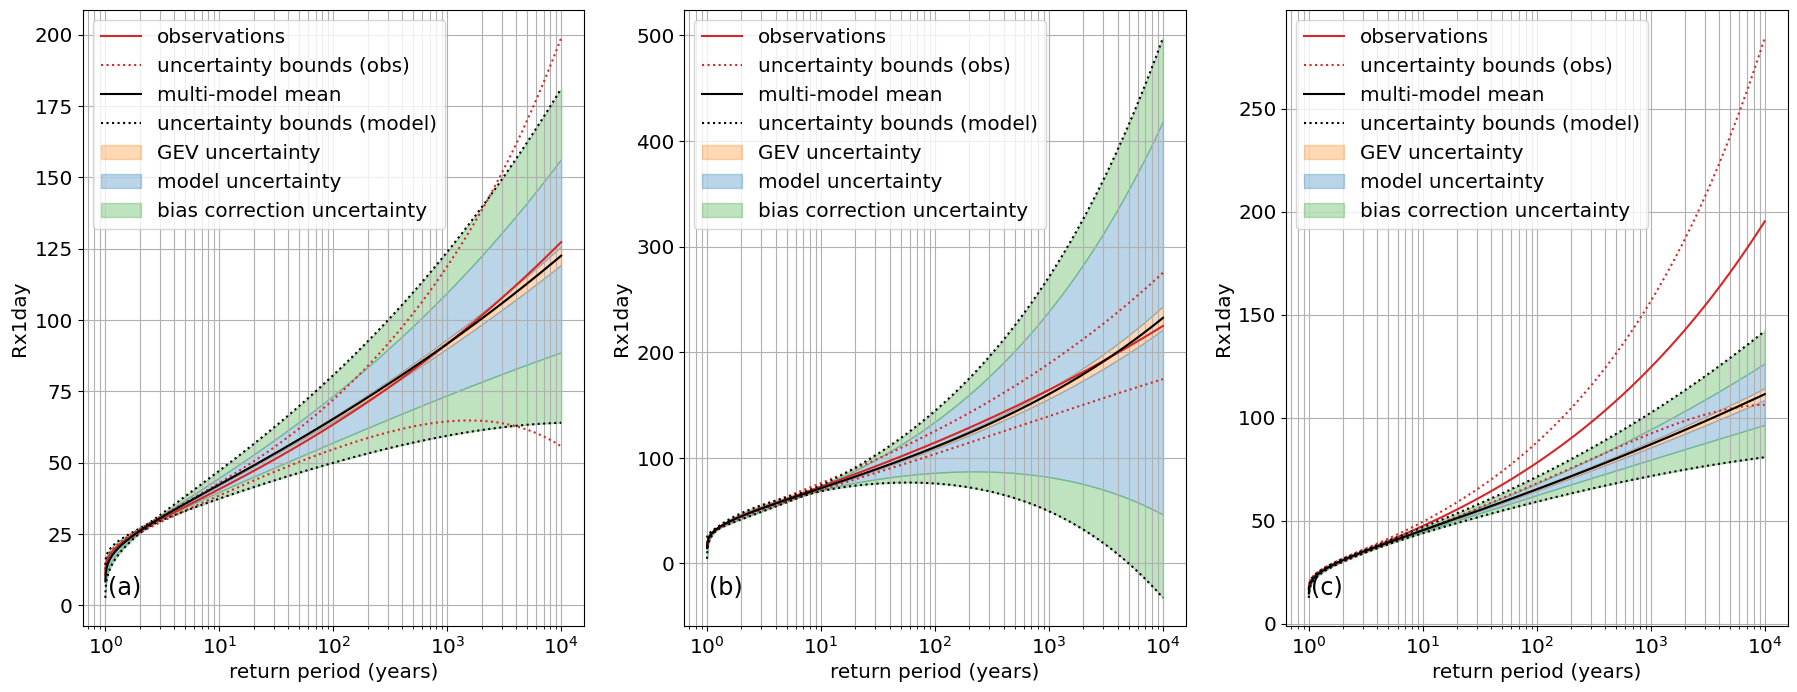

In [8]:
fig = plt.figure(figsize=[22, 8])

ax1 = fig.add_subplot(131)
plot_uncertainty(ax1, metric, return_df1, gev_spread_df1, ylim=[], letter='a')

ax2 = fig.add_subplot(132)
plot_uncertainty(ax2, metric, return_df2, gev_spread_df2, ylim=[], letter='b')

ax3 = fig.add_subplot(133)
plot_uncertainty(ax3, metric, return_df3, gev_spread_df3, ylim=[], letter='c')

plt.savefig('figures/rx1day_uncertainty.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

## TXx

In [5]:
metric = 'txx'

In [6]:
location4 = [7, 10]
model_dict4 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
#    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df4, gev_spread_df4 = get_return_values(metric, location4, model_dict4)

BCC-CSM2-MR
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


In [7]:
location5 = [3, 2]
model_dict5 = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}
return_df5, gev_spread_df5 = get_return_values(metric, location5, model_dict5)

BCC-CSM2-MR
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


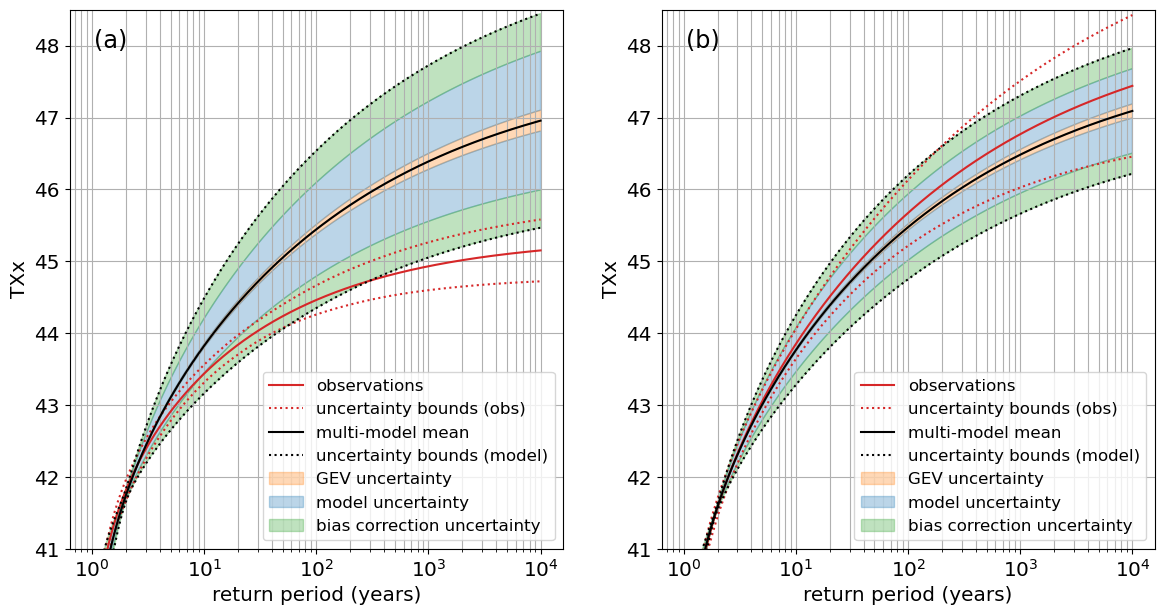

In [25]:
fig = plt.figure(figsize=[14, 7])

ax4 = fig.add_subplot(121)
plot_uncertainty(ax4, metric, return_df4, gev_spread_df4, ylim=[41, 48.5], letter='a')

ax5 = fig.add_subplot(122)
plot_uncertainty(ax5, metric, return_df5, gev_spread_df5, ylim=[41, 48.5], letter='b')

plt.savefig('figures/txx_uncertainty.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()